In [3]:
import sys
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
raiz_projeto = Path().resolve().parent
sys.path.append(str(raiz_projeto))
from scripts.dataLoader import carregar_dados

df_brasileirao, df_copa = carregar_dados()
from IPython.display import Markdown, display

import locale

# Configura o ambiente para o padrão brasileiro
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except locale.Error:
    locale.setlocale(locale.LC_ALL, 'pt_BR')

 Data Base carregadas com sucesso.


In [4]:
total_b = locale.format_string('%d', df_brasileirao.shape[0], grouping=True)
total_gols_mandante_b = locale.format_string('%d', df_brasileirao['gols_mandante'].sum(), grouping=True)
total_gols_visitante_b = locale.format_string('%d', df_brasileirao['gols_visitante'].sum(), grouping=True)
media_gols_brasileirao = locale.format_string('%.2f', df_brasileirao['gols_mandante'].mean() + df_brasileirao['gols_visitante'].mean(), grouping=True)
total_publico_b = locale.format_string('%d', df_brasileirao['publico'].sum(), grouping=True)
media_publico_b = locale.format_string('%.2f', df_brasileirao['publico'].mean(), grouping=True)

total_c = locale.format_string('%d', df_copa.shape[0], grouping=True)
total_gols_mandante_c = locale.format_string('%d', df_copa['gols_mandante'].sum(), grouping=True)
total_gols_visitante_c = locale.format_string('%d', df_copa['gols_visitante'].sum(), grouping=True)
media_gols_copa = locale.format_string('%.2f', df_copa['gols_mandante'].mean() + df_copa['gols_visitante'].mean(), grouping=True)
total_publico_c = locale.format_string('%d', df_copa['publico'].sum(), grouping=True)
media_publico_c = locale.format_string('%.2f', df_copa['publico'].mean(), grouping=True)

relatorio = f"""
### Brasileirão Série A
* **Total de Partidas:** `{total_b}`
* **Gols marcados pelo Mandante:** `{total_gols_mandante_b}`
* **Gols marcados pelo Visitante:** `{total_gols_visitante_b}`
* **Média de Gols por Jogo:** `{media_gols_brasileirao}`
* **Público Total:** `{total_publico_b}`
* **Público Médio por Jogo:** `{media_publico_b}`

---

### Copa do Brasil
* **Total de Partidas:** `{total_c}`
* **Gols marcados pelo Mandante:** `{total_gols_mandante_c}`
* **Gols marcados pelo Visitante:** `{total_gols_visitante_c}`
* **Média de Gols por Jogo:** `{media_gols_copa}`
* **Público Total:** `{total_publico_c}`
* **Público Médio por Jogo:** `{media_publico_c}`
"""

display(Markdown(relatorio))


### Brasileirão Série A
* **Total de Partidas:** `8.453`
* **Gols marcados pelo Mandante:** `12.916`
* **Gols marcados pelo Visitante:** `8.647`
* **Média de Gols por Jogo:** `2,55`
* **Público Total:** `109.152.656`
* **Público Médio por Jogo:** `16.189,95`

---

### Copa do Brasil
* **Total de Partidas:** `598`
* **Gols marcados pelo Mandante:** `746`
* **Gols marcados pelo Visitante:** `646`
* **Média de Gols por Jogo:** `2,33`
* **Público Total:** `5.619.597`
* **Público Médio por Jogo:** `9.397,32`


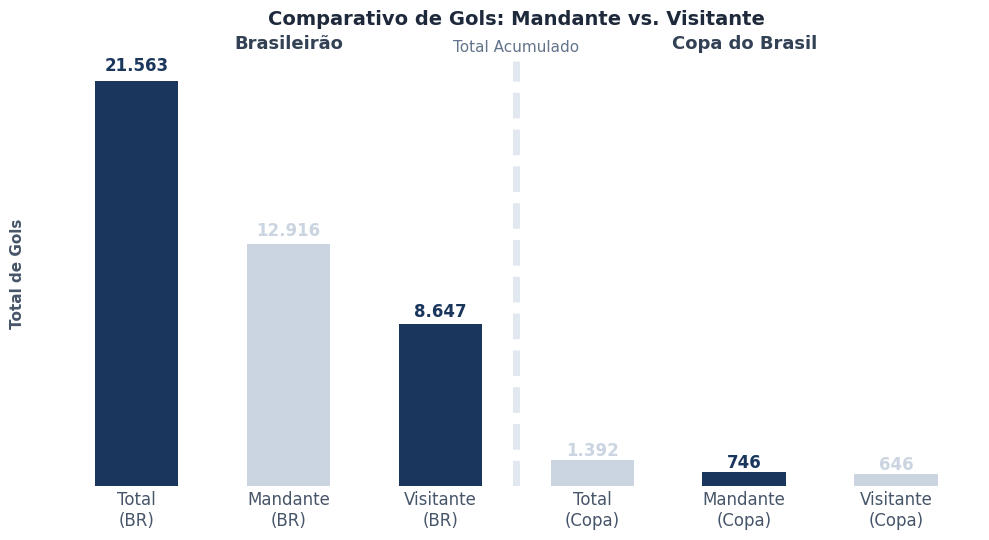

In [5]:
categoria = ['Total\n(BR)','Mandante\n(BR)', 'Visitante\n(BR)','Total\n(Copa)', 'Mandante\n(Copa)', 'Visitante\n(Copa)']

gols_total_br = [df_brasileirao['gols_mandante'].sum() + df_brasileirao['gols_visitante'].sum()]
gols_brasileirao = [df_brasileirao['gols_mandante'].sum(), df_brasileirao['gols_visitante'].sum()]

gols_total_copa = [df_copa['gols_mandante'].sum() + df_copa['gols_visitante'].sum()]
gols_copa = [df_copa['gols_mandante'].sum(), df_copa['gols_visitante'].sum()]

gols = gols_total_br + gols_brasileirao + gols_total_copa + gols_copa #lista de gols para cada categoria
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='white')

cores = ['#1A365D', '#CBD5E1','#1A365D', '#CBD5E1','#1A365D', '#CBD5E1']
barras = ax.bar(categoria, gols, color=cores, width=0.55, edgecolor='none')

ax.set_title('Comparativo de Gols: Mandante vs. Visitante\n', 
             fontsize=14, fontweight='bold', color='#1E293B', loc='center', pad=10)
ax.text(
    1,                    
    max(gols) * 1.08,     
    'Brasileirão',
    ha='center',
    fontsize=13,
    fontweight='bold',
    color='#334155'
)

ax.text(
    4,                    
    max(gols) * 1.08,
    'Copa do Brasil',
    ha='center',
    fontsize=13,
    fontweight='bold',
    color='#334155',

)
ax.text(0.5, 1.02, 'Total Acumulado', 
        transform=ax.transAxes, fontsize=11, color='#64748B', ha='center')

ax.set_ylabel('Total de Gols', fontsize=11, fontweight='semibold', color='#475569', labelpad=20)
ax.tick_params(axis='x', colors='#475569', labelsize=12, length=0)
ax.tick_params(axis='y', left=False, labelleft=False) 

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

for barra, cor in zip(barras, cores):
    altura = barra.get_height()
    deslocamento = altura * 0.015 
    
    ax.text(barra.get_x() + barra.get_width()/2, altura + deslocamento, 
            f'{int(altura):,}'.replace(',', '.'), 
            ha='center', va='bottom', fontsize=12, fontweight='bold', color=cor)
    
ax.axvline(x=2.5, color='#E2E8F0', linestyle='--', linewidth=5) #Adicionando uma linha vertical sutil para separar os campeonatos

plt.tight_layout()
plt.show()

In [6]:
mais_apitados_BR = df_brasileirao["arbitro"].value_counts().head(10)

mais_apitados_CB = df_copa["arbitro"].value_counts().head(10)

brasileirao = "\n".join(
    f"{i+1}. **{arbitro}** — {qtd} jogos"
    for i, (arbitro, qtd) in enumerate(mais_apitados_BR.items())
)

copabrasil = "\n".join(
    f"{i+1}. **{arbitro}** — {qtd} jogos"
    for i, (arbitro, qtd) in enumerate(mais_apitados_CB.items())
)

mais_apitados_relatorio = f"""
### Árbitros mais Apitados
* **Brasileirão Série A**
{brasileirao}

* **Copa do Brasil**
{copabrasil}
"""



display(Markdown(mais_apitados_relatorio))


### Árbitros mais Apitados
* **Brasileirão Série A**
1. **Leandro Pedro Vuaden** — 284 jogos
2. **Wilton Sampaio** — 253 jogos
3. **Anderson Daronco** — 224 jogos
4. **Héber Lopes** — 221 jogos
5. **Raphael Claus** — 212 jogos
6. **Ricardo Marques Ribeiro** — 208 jogos
7. **Marcelo de Lima Henrique** — 205 jogos
8. **Luiz Flávio de Oliveira** — 158 jogos
9. **Braulio da Silva Machado** — 157 jogos
10. **Péricles Bassols Pegado Cortez** — 144 jogos

* **Copa do Brasil**
1. **Braulio da Silva Machado** — 15 jogos
2. **Anderson Daronco** — 14 jogos
3. **Raphael Claus** — 13 jogos
4. **Wilton Sampaio** — 12 jogos
5. **Marcelo de Lima Henrique  (RJ)** — 9 jogos
6. **Bruno Arleu de Araújo** — 8 jogos
7. **Wagner do Nascimento Magalhães** — 7 jogos
8. **Felipe Fernandes** — 6 jogos
9. **Caio Max Augusto Vieira** — 6 jogos
10. **Ramon Abatti** — 6 jogos


In [7]:
estadios_jogos_br = df_brasileirao["estadio"].value_counts().head(10)

estadios_jogos_cb = df_copa["estadio"].value_counts().head(10)

brasileirao = "\n".join(
    f"{i+1}. **{estadio}** — {qtd} jogos"
    for i, (estadio, qtd) in enumerate(estadios_jogos_br.items())
)

copabrasil = "\n".join(
    f"{i+1}. **{estadio}** — {qtd} jogos"
    for i, (estadio, qtd) in enumerate(estadios_jogos_cb.items())
)

mais_apitados_relatorio = f"""
### Estádios com mais jogos
* **Brasileirão Série A**
{brasileirao}

* **Copa do Brasil**
{copabrasil}
"""



display(Markdown(mais_apitados_relatorio))


### Estádios com mais jogos
* **Brasileirão Série A**
1. **Estádio Jornalista Mário Filho** — 798 jogos
2. **Estádio Governador Magalhães Pinto** — 518 jogos
3. **Estádio Cícero Pompeu de Toledo** — 399 jogos
4. **Estádio Beira-Rio** — 371 jogos
5. **Estádio Urbano Caldeira** — 369 jogos
6. **Arena da Baixada** — 336 jogos
7. **Allianz Parque** — 332 jogos
8. **Estádio Raimundo Sampaio** — 305 jogos
9. **Estádio Olímpico Nilton Santos** — 298 jogos
10. **Estádio Governador Plácido Castelo** — 296 jogos

* **Copa do Brasil**
1. **Estádio Jornalista Mário Filho** — 32 jogos
2. **Estádio Governador Plácido Castelo** — 22 jogos
3. **Estádio Raimundo Sampaio** — 18 jogos
4. **Estádio Cícero Pompeu de Toledo** — 16 jogos
5. **Ligga Arena** — 14 jogos
6. **Estádio Rei Pelé** — 14 jogos
7. **Estádio Antonio Accioly** — 13 jogos
8. **Neo Química Arena ** — 13 jogos
9. **Arena do Grêmio** — 12 jogos
10. **Allianz Parque** — 11 jogos


### O quanto torcida influencia no desempenho do time?